# Feature Engineering

本ノートブックでは、`01_EDA.ipynb`・`02_preprocessing.ipynb` の知見をもとに、モデル精度を高めるための特徴量を段階的に設計・検証する。

特徴量の生成ロジックは最終的に `src/features.py` に集約しているが、ここではその設計過程と各段階での CV スコアの推移を記録し、**なぜその特徴量を採用（または不採用）としたか**を示すことを目的とする。

In [4]:
import sys
import warnings

sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from src.preprocessing import impute_missing, convert_types
from src.features import (
    add_features, add_neighborhood_features,
    add_target_encoding_features, FEATURES,
)
from src.utils import run_cv, seed_everything, make_submission

SEED = 123
seed_everything(SEED)

## 1. データ準備

前処理済みデータを作成する。処理の詳細は `02_preprocessing.ipynb` および `src/preprocessing.py` を参照。

In [5]:
train_df = pd.read_csv("../data/train.csv")
test_df  = pd.read_csv("../data/test.csv")

y = train_df["SalePrice"]
train_df = train_df.drop("SalePrice", axis=1)

df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

df = impute_missing(df)
df = convert_types(df)

print("shape:", df.shape)

shape: (2919, 80)


## 2. 特徴量エンジニアリング

### 2.1 基本派生特徴量の追加（CV 0.218 → 0.148）

#### 実施内容
住宅価格に直結しやすいと考えた **広さ・品質・築年数** に着目し、
元データの情報を要約・補強する基本的な派生特徴量を作成した。

- `TotalSF`：地上居住面積と地下室面積を合算した総面積
- `Qual_TotalSF`：品質と面積を掛け合わせた特徴量
- `HouseAge`：販売時点での築年数

```python
#  基本派生特徴量の追加
df["TotalSF"] = df["GrLivArea"] + df["TotalBsmtSF"]
df["Qual_TotalSF"] = df["OverallQual"] * df["TotalSF"]
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
```

#### 結果
基本派生特徴量の追加により、CVは **0.218 → 0.148** まで大きく改善した。  
特徴量エンジニアリングの初期段階では、複雑な加工よりも、元データの意味を保ちながら情報量を補強する特徴量が有効であることが分かった。

| 施策 | CV |
|---|---:|
| ベースライン | 0.218 |
| 基本派生特徴量追加後 | 0.148 |

#### 考察
特に **面積** と **品質** は住宅価格との関係が強く、両者を組み合わせた特徴量が有効だった。  
一方で、CVは **0.148付近で頭打ち** となり、単純な派生特徴量の追加だけでは改善が鈍化し始めた。  
この結果から、以降は数値特徴の単純な補強ではなく、`Neighborhood` のようなカテゴリ情報を活用する方向へ検証を広げた。

### 2.2 Neighborhood情報を活用した特徴量の追加（CV 0.148 → 0.143）

#### 実施内容
2.1 の数値特徴だけでは CV が 0.148 付近で頭打ちになったため、  
次に **立地情報である `Neighborhood` をどう活かすか** を検証した。 

不動産価格は物件単体のスペックだけでなく、**立地の価格帯と物件の強さの掛け合わせ**で決まる。  
例えば同じ広さ・品質の住宅でも、高価格帯の地域にあるかどうかで価格は大きく変わる。  
この関係を表現するため、`Neighborhood` の Target Encoding（TE）を土台に、品質・面積との交互作用特徴量を作成した。

`Neighborhood_TE` はリークを避けるため、`src/features.py` 内で  
KFold ベースで学習データとテストデータを分けて作成している。  
ここでは、作成済みの `Neighborhood_TE` を用いた交互作用特徴量のみを掲載する。

```python
# 地域の価格傾向と、品質情報を組み合わせた特徴量
df["Neighborhood_Qual"] = df["Neighborhood_TE"] * df["OverallQual"]
# 地域の価格傾向と、面積情報を組み合わせた特徴量
df["Neighborhood_SF"] = df["Neighborhood_TE"] * df["GrLivArea"]
# 地域の価格傾向と、品質 × 地下室を含む総面積を組み合わせた特徴量
df["Neighborhood_TotalQual_SF"] = df["Neighborhood_TE"] * df["TotalQual_SF"]
```

#### 結果
`Neighborhood` 系特徴量の中では、**`Neighborhood_TotalQual_SF` が最も大きく CV と LB を改善** した。  
また、`Neighborhood_Qual` と `Neighborhood_SF` も一定の効果があり、最終特徴量として採用した。

#### 考察
`Neighborhood` の情報は単体で持たせるだけではなく、**品質や面積といった主要特徴と組み合わせることで有効性が高まる** ことが分かった。  
特に `Neighborhood_TE` を土台にした特徴量は、地域の価格傾向と住宅の強さをあわせて表現できていたと考えられる。

### 2.3 元カラムの再評価と再追加（CV 0.143 → 0.129）

#### 実施内容
2.1, 2.2 では派生特徴量を中心に追加してきたが、改善が頭打ちになったため、特徴量設計の方針自体を見直した。  
この段階で、派生特徴量によって情報を要約することに意識が寄りすぎ、**元カラムが持つ生の情報を十分に活かせていない可能性** があると考えた。  
そこで、価格予測に関係が強そうな元カラムを段階的に再追加し、CVとLBの変化を確認した。

```python
# 元カラムの再追加例
features = features + [
    "OverallCond", "LotArea", "YearBuilt", "FullBath", "TotRmsAbvGrd"
]
```

#### 結果

元カラムを再追加したことで、CVは 0.143 → 0.129、LBは 0.151 → 0.130 まで改善した。
また、CVとLBの乖離も小さくなり、**過学習も抑えられる傾向**が見られた。

#### 考察

派生特徴量は有効だった一方で、元カラムを完全には代替できなかった。
元カラムを残すことで情報が補われ、汎化性能の改善にもつながったと考えられる。

この結果から、特徴量エンジニアリングでは「新しい特徴量を作ること」だけでなく、**元の情報をどこまで残すか** も重要だと学んだ。

### 2.4 EDAを踏まえた追加検証と不採用施策の整理

#### 実施内容
2.3 で元カラムを再追加した後、特徴量の分布や外れ値の影響をより深く把握するために EDA を行った。（詳細は `01_EDA.ipynb` に記載）

その結果、`SalePrice` は強い右裾を持つ分布であり、`GrLivArea` や `TotalBsmtSF` には外れ値候補が見られた。また、`LotArea` や `OpenPorchSF` など歪度の高い変数も残っていた。こうした観察結果を踏まえ、**log変換・外れ値クリップ・3way交互作用特徴量** を追加で検証した。 

#### 結果
これらの施策はいずれも明確な改善にはつながらず、最終的には不採用とした。
| 施策 | 仮説 | 結果 | 判断 |
|---|---|---|---|
| log変換 | 歪みの強い分布を整えることで予測が安定する | CV・LBともに明確な改善なし | 不採用 |
| 外れ値クリップ | 極端値の影響を抑えることで汎化性能が向上する | 改善なし | 不採用 |
| 3way交互作用 | 変数間の複雑な関係をより直接表現できる | 改善なし | 不採用 |


#### 考察
今回の検証では、**EDAで把握できた課題が、そのまま LightGBM の精度改善にはつながらなかった。**  
その理由として、今回使用した LightGBM は木モデルであり、線形モデルほど分布の歪み補正の恩恵を受けにくかった可能性がある。  
また、EDA上で外れ値に見えたデータも、単なるノイズではなく価格差を説明する情報を含んでいた可能性があり、一律にクリップすることで有効な差を弱めてしまったと考えられる。

3way交互作用特徴量についても、EDAで相関の強い変数群や多重共線性のある組み合わせは確認できたものの、今回のモデルでは複雑な組み合わせを明示的に追加するより、すでに有効だった特徴量から木構造で関係を学習させる方が適していたと考えられる。  
つまり、**EDAで課題を発見することと、実際にモデルが改善することは別問題** だった。

これを通じて、施策を選ぶ際にはデータの見え方だけでなく、**アルゴリズムの特性まで含めて施策を選ぶ必要がある** と理解した。  
また、仮説検証を繰り返す中で「効かなかった施策」も記録として残すことが、分析プロセスを示すうえで重要だと学んだ。

## 3. 最終採用特徴量

### 3.1 特徴量一覧
最終的に採用した特徴量は、元カラム・基本派生特徴量・Neighborhood系特徴量・地下室／ガレージ系特徴量・補助特徴量に分類できる。  

In [19]:
# 最終採用特徴量をカテゴリごとに整理
feature_groups = {
    "基本数値・元カラム": [
        "OverallQual", "GrLivArea", "GarageCars", "GarageArea",
        "TotalBsmtSF", "YearBuilt", "FullBath", "TotRmsAbvGrd",
        "YearRemodAdd", "LotFrontage", "MasVnrArea", "WoodDeckSF",
        "OpenPorchSF", "BsmtFinSF1", "OverallCond", "LotArea",
        "Condition1", "LotShape", "LandContour", "Fireplaces",
    ],
    "面積・品質・築年数系の派生特徴量": [
        "TotalSF_with_porch", "TotalBath", "TotalQual_SF",
        "HouseAge", "RemodAge", "TotalQual", "Qual_Remod",
        "KitchenScore", "Lot_Score",
    ],
    "Neighborhood系特徴量": [
        "Neighborhood_TotalQual_SF", "Neighborhood_Qual",
        "Neighborhood_SF", "GrLivArea_ratio",
    ],
    "地下室・ガレージ系特徴量": [
        "BsmtQual_TotalSF", "GarageFinish_num", "GarageScore",
        "Garage_SF", "Bsmt_Liv",
    ],
    "補助的なスコア・フラグ特徴量": [
        "HasFireplace", "Functional_num", "MSZoning_num",
        "SaleCondition_num", "ExteriorQual", "BsmtScore",
        "ConditionScore",
    ],
}

group_df = pd.DataFrame({
    group_name: pd.Series(cols)
    for group_name, cols in feature_groups.items()
}).fillna("")

group_df.index = group_df.index + 1
group_df

,基本数値・元カラム,面積・品質・築年数系の派生特徴量,Neighborhood系特徴量,地下室・ガレージ系特徴量,補助的なスコア・フラグ特徴量
1,OverallQual,TotalSF_with_porch,Neighborhood_TotalQual_SF,BsmtQual_TotalSF,HasFireplace
2,GrLivArea,TotalBath,Neighborhood_Qual,GarageFinish_num,Functional_num
3,GarageCars,TotalQual_SF,Neighborhood_SF,GarageScore,MSZoning_num
4,GarageArea,HouseAge,GrLivArea_ratio,Garage_SF,SaleCondition_num
5,TotalBsmtSF,RemodAge,,Bsmt_Liv,ExteriorQual
6,YearBuilt,TotalQual,,,BsmtScore
7,FullBath,Qual_Remod,,,ConditionScore
8,TotRmsAbvGrd,KitchenScore,,,
9,YearRemodAdd,Lot_Score,,,
10,LotFrontage,,,,


### 3.2 CV 確認

最終採用特徴量を用いて LightGBM の CV を実行し、特徴量設計全体の効果を確認する。
**以降は `src/features.py` に集約した最終版の特徴量生成処理を用いて、学習・評価を行う。**

In [24]:
df = add_features(df)
train = df.iloc[:len(y)].copy()
test  = df.iloc[len(y):].copy()

train = add_neighborhood_features(train, train)
test  = add_neighborhood_features(test, train)

# KFold Target Encoding
train["SalePrice"] = y.values
train, test = add_target_encoding_features(train, test, target_col="SalePrice")
train = train.drop("SalePrice", axis=1)

X_train = train[FEATURES]
y_train = np.log1p(y)
X_test  = test[FEATURES]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (1460, 45)
X_test:  (1459, 45)


In [23]:
params = {
    "boosting_type" : "gbdt",
    "objective"     : "regression",
    "metric"        : "rmse",
    "learning_rate" : 0.1,
    "num_leaves"    : 16,
    "n_estimators"  : 100000,
    "random_state"  : 123,
    "importance_type": "gain",
}

lgb_model = lgb.LGBMRegressor(**params)
metrics_lgb, imp_lgb = run_cv(lgb_model, X_train, y_train, random_state=SEED)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5126
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 45
[LightGBM] [Info] Start training from score 12.021806
[fold 0] tr: 0.05710, va: 0.11587
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000428 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5109
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 45
[LightGBM] [Info] Start training from score 12.014343
[fold 1] tr: 0.07280, va: 0.13614
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000416 seconds.
You can set `for

## 4. ベースラインとの比較

`00_baseline.ipynb` で作成したベースラインモデルでは、CV は **0.211**、LB は **0.218** だった。  
一方、特徴量エンジニアリング後の最終採用特徴量を用いたモデルでは、CV は **0.129**、LB は **0.130** まで改善した。  
これにより、特徴量設計を通じてローカル検証・提出結果の両方で大きな改善を確認できた。

Final の CV は本ノートブックでの最終採用特徴量による LightGBM の検証結果、LB は submission_03 の提出結果である。

| 指標 | Baseline | Final |
|---|---:|---:|
| CV | 0.211 | 0.129 |
| LB | 0.218 | 0.130 |

## 5. 特徴量重要度

最終採用特徴量が実際にどの程度モデルに寄与していたかを確認するため、LightGBM の特徴量重要度を可視化した。  
どの特徴量が予測に強く効いていたのかを把握し、特徴量設計の妥当性を検証することを目的とする。

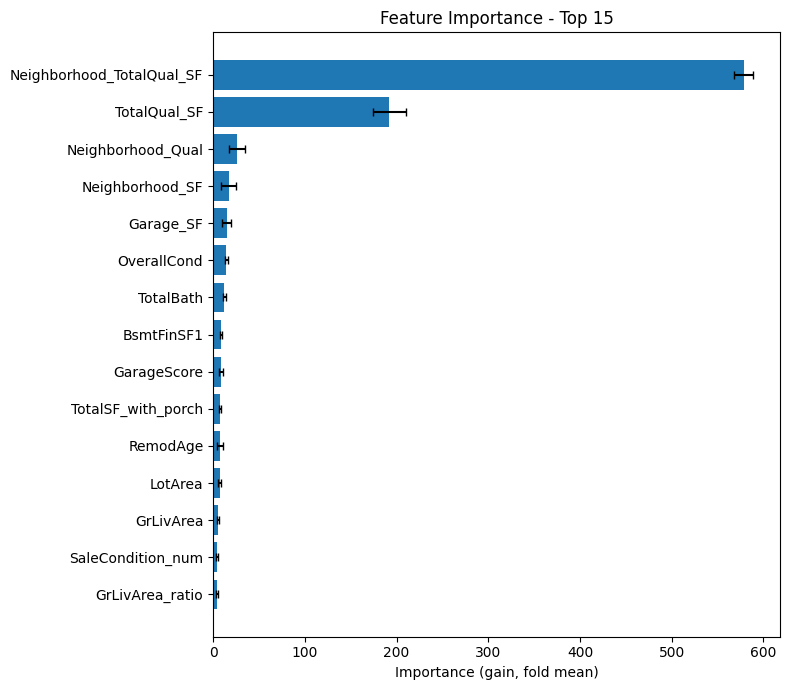

In [11]:
# 特徴量重要度 上位15件 棒グラフ
top20 = imp_lgb.head(15).sort_values("imp")

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20.index, top20["imp"], xerr=top20["imp_std"], capsize=3)
ax.set_xlabel("Importance (gain, fold mean)")
ax.set_title("Feature Importance - Top 15")
plt.tight_layout()
plt.show()

#### 考察

最終採用特徴量を用いた LightGBM の特徴量重要度を確認したところ、**`Neighborhood_TotalQual_SF` が最も高く、次いで `TotalQual_SF` が大きく寄与していた。**  
このことから、住宅価格予測では、単一の元カラムよりも **「品質 × 面積」** や **「地域情報 × 品質・面積」** のような交互作用特徴量が特に有効だったと分かる。

また、`Neighborhood_Qual` や `Neighborhood_SF` も上位に入っており、`Neighborhood_TE` を土台にした特徴量が有効に機能していた。  
これは、地域ごとの価格傾向と物件そのものの広さ・品質を組み合わせることで、住宅の相対的な価値をより適切に表現できていたためだと考えられる。

一方で、`Garage_SF`、`TotalBath`、`OverallCond` なども一定の寄与を示しており、主要な交互作用特徴量だけでなく、住宅の設備や状態に関する補助的な特徴量も予測精度の向上に貢献していた。  

以上より、最終的な特徴量設計では、**元カラム・基本派生特徴量・Neighborhood 系特徴量を組み合わせる方針が妥当だった** と確認できた。

In [13]:
# 全データで再学習 → submission
model = lgb.LGBMRegressor(**params)
model.fit(X_train, y_train)

make_submission(
    model, X_test, test["Id"],
    filepath="../submissions/submission_03_feature_engineering.csv"
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000775 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5321
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 45
[LightGBM] [Info] Start training from score 12.024057
Saved: ../submissions/submission_03_feature_engineering.csv


,Id,SalePrice
1460,1461,115644.623839
1461,1462,165821.392482
1462,1463,186303.746617
1463,1464,189743.013447
1464,1465,184737.800070
...,...,...
2914,2915,74940.514333
2915,2916,79073.180122
2916,2917,162738.881366
2917,2918,120121.930485


## 6. Summary

本ノートブックでは、House Prices コンペにおいて特徴量エンジニアリングを段階的に行い、CV **0.211 → 0.129**、LB **0.218 → 0.130** まで改善した。

改善に最も寄与したのは、2.3 の**元カラムの再追加**（CV 0.143 → 0.129）だった。  
派生特徴量の設計に集中するあまり、元カラムが持つ生の情報を捨てていたことに気づき、方針を転換したことが最大の転機となった。

特徴量重要度では `Neighborhood_TotalQual_SF` や `TotalQual_SF` が上位を占め、**品質・面積・地域情報の交互作用**が価格予測に強く寄与していた。  
一方で、元カラム群もモデルに一定の寄与を示しており、派生特徴量は元カラムの「代替」ではなく「補強」として機能していたことが確認できた。

2.4 では EDA の知見をもとに log変換・外れ値クリップ・3way交互作用を試したが、いずれも改善につながらなかった。  
これは LightGBM が木構造であるため、分布補正や外れ値処理の恩恵を受けにくかったことが主因と考えられる。  
**EDA で課題を発見することと、それがモデル改善に直結することは別問題**であり、アルゴリズムの特性を踏まえて施策を選ぶ必要があると学んだ。

全体を通じて得た学びは以下の3点である。

- **元の情報を安易に捨てない。** → 派生特徴量で要約しきれない情報が元カラムに残っている
- **アルゴリズムの特性を考慮して施策を選ぶ。** → EDA の発見がそのまま精度改善になるとは限らない
- **効かなかった施策も記録する。** → 不採用の判断根拠を残すことが、分析プロセスの信頼性につながる